Dataset shape: (144, 1)
            passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Freq: MS
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None

Missing values: 0


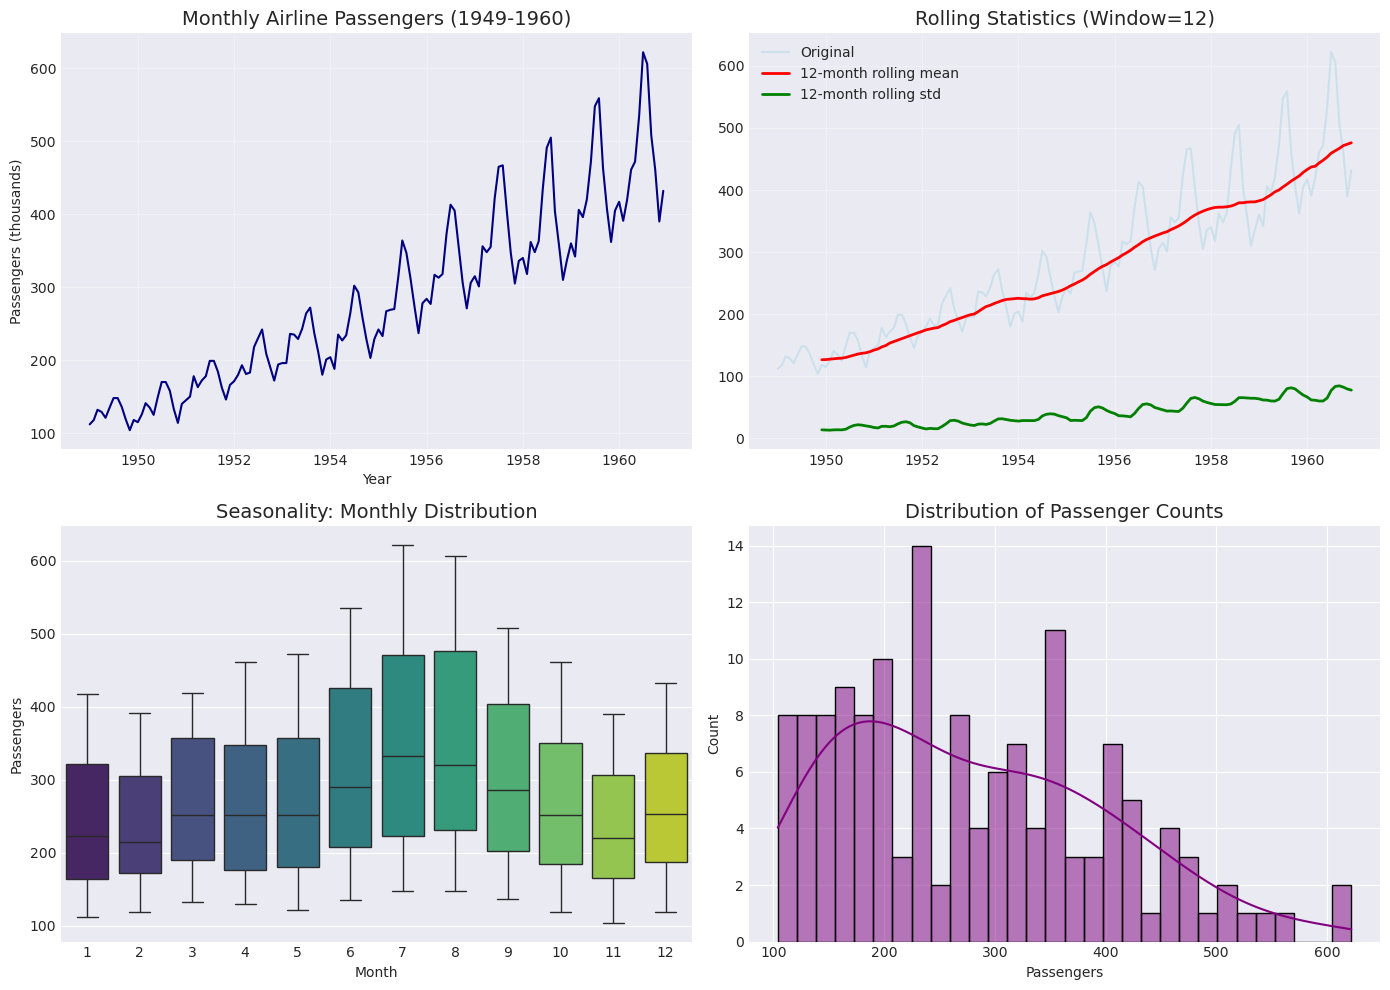


--- ADF Test: Original Series ---
ADF Statistic: 0.8154
p-value: 0.9919
Critical Values:
	1%: -3.4817
	5%: -2.8840
	10%: -2.5788
❌ Series is NON-STATIONARY (fail to reject H0)

--- ADF Test: Combined Differencing (d=1, D=1) ---
ADF Statistic: -15.5956
p-value: 0.0000
Critical Values:
	1%: -3.4817
	5%: -2.8840
	10%: -2.5788
✅ Series is STATIONARY (reject H0)


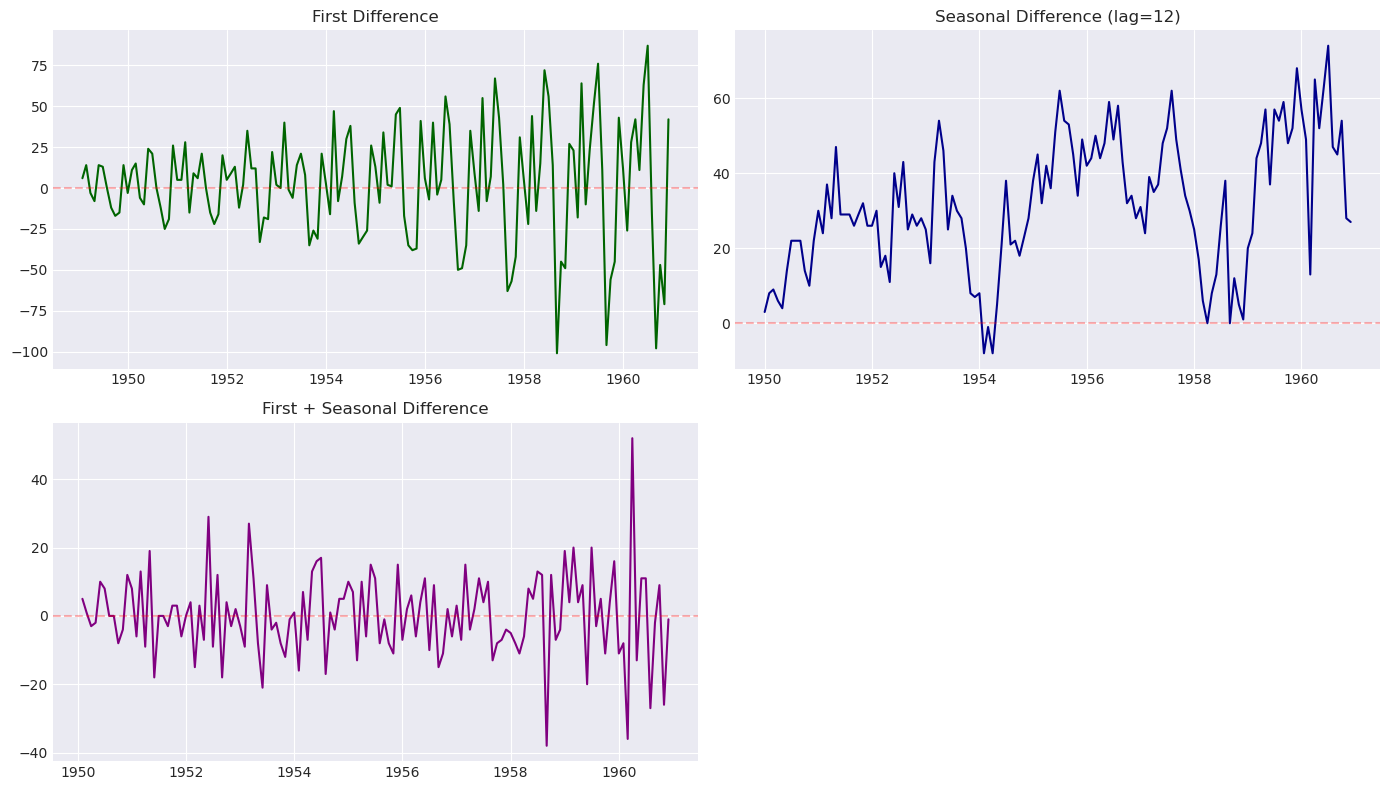

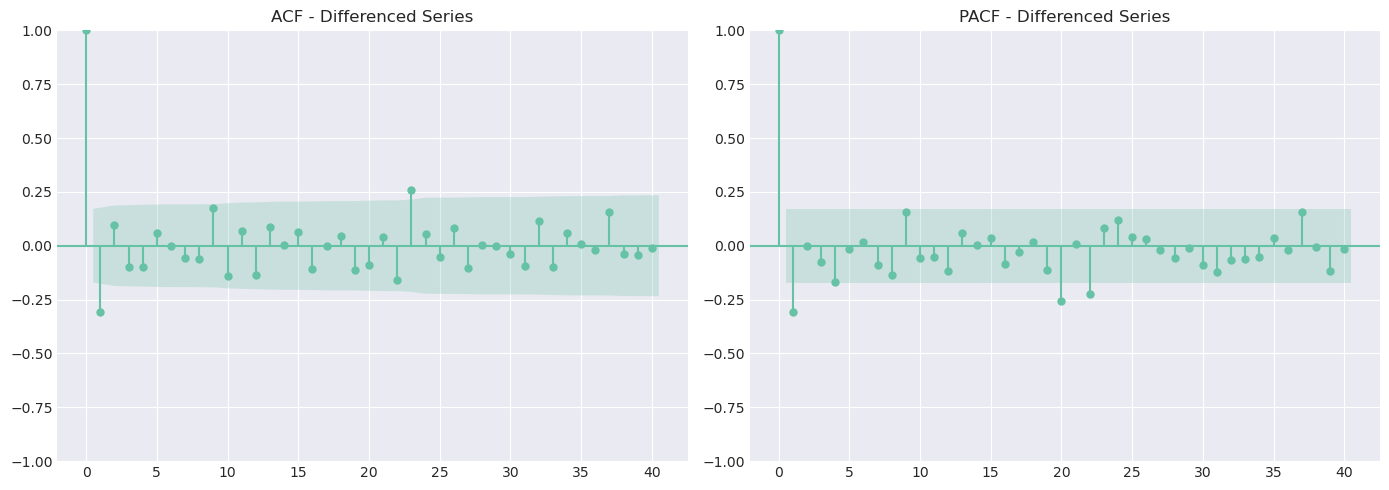


Training set: 115 observations
Test set: 29 observations
                                      SARIMAX Results                                      
Dep. Variable:                          passengers   No. Observations:                  115
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -368.442
Date:                             Mon, 06 Jul 2026   AIC                            744.884
Time:                                     23:36:27   BIC                            755.305
Sample:                                 01-01-1949   HQIC                           749.102
                                      - 07-01-1958                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5733      0.733     -0.782     

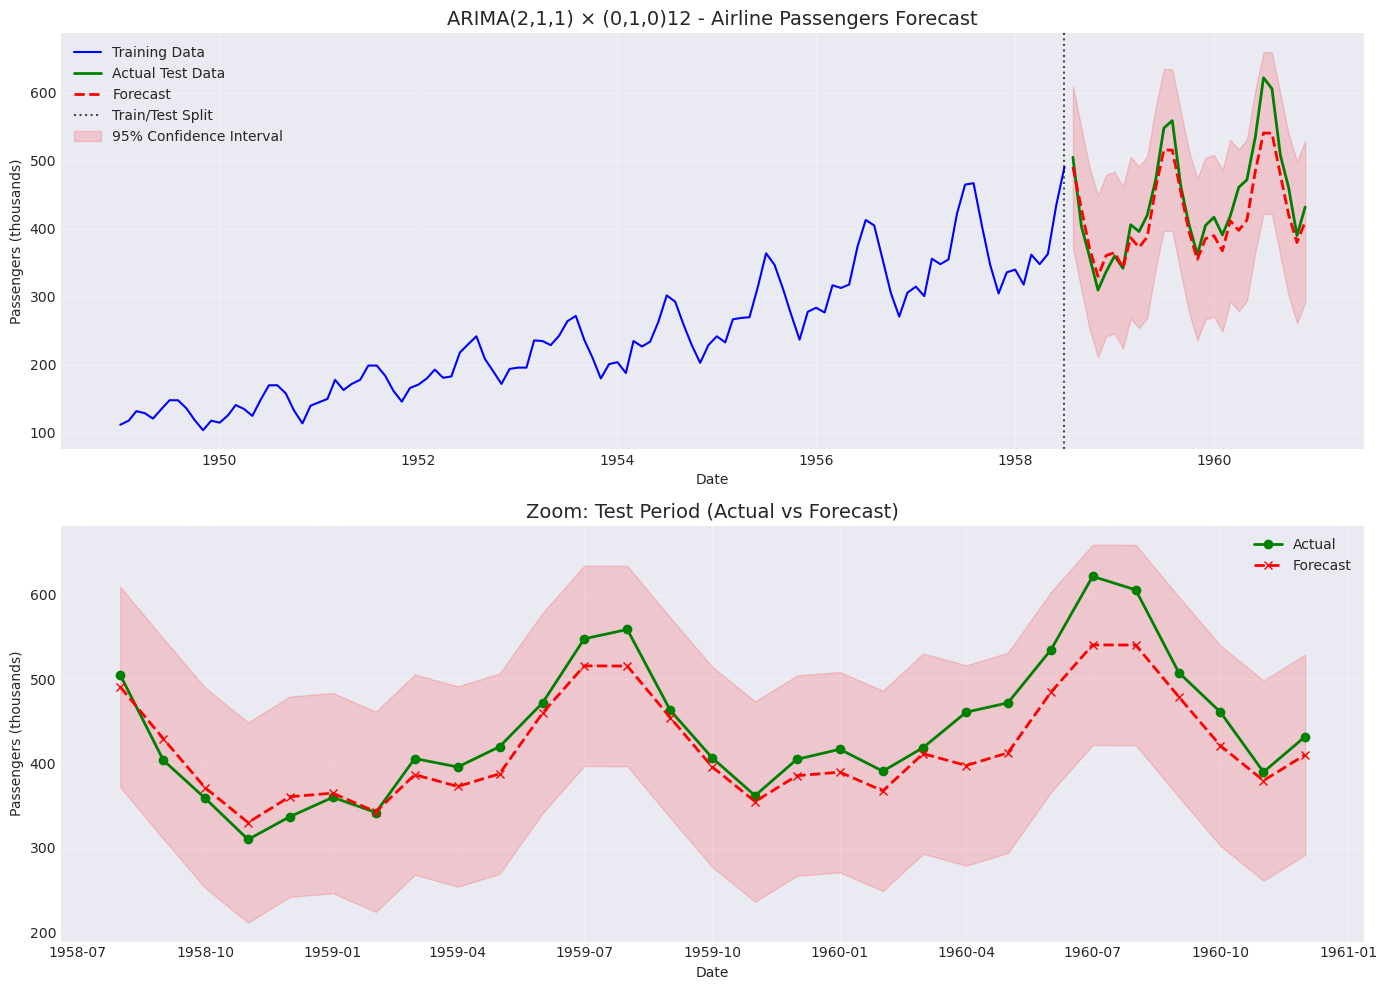

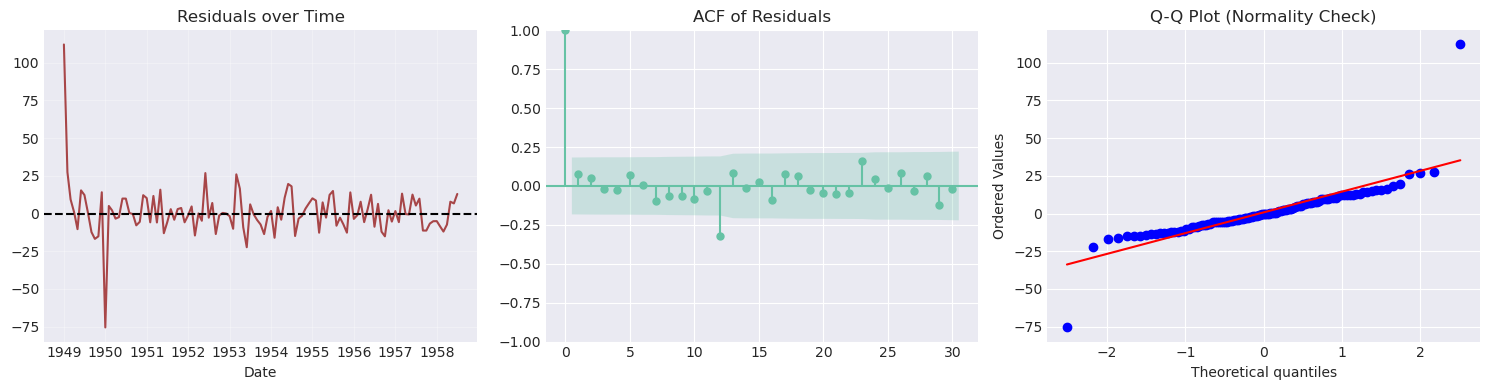


Ljung-Box Test (H0: No autocorrelation):
     lb_stat  lb_pvalue
1   0.660956   0.416223
2   0.934662   0.626673
3   0.969162   0.808713
4   1.060349   0.900511
5   1.687502   0.890471
6   1.688885   0.945976
7   2.832441   0.900058
8   3.395106   0.907176
9   3.880980   0.919070
10  4.772534   0.905846


In [2]:
# ================================
# 1. IMPORTS
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# For auto_arima (optional - install with: pip install pmdarima)
# from pmdarima import auto_arima

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# ================================
# 2. LOAD DATASET (Airline Passengers)
# ================================
# Classic dataset - 144 monthly observations (1949-1960)
# For ≥200, use daily data (see alternative below)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.columns = ['passengers']
df = df.asfreq('MS')  # Set monthly frequency

print(f"Dataset shape: {df.shape}")
print(df.head())
print(df.info())

# ================================
# 3. HANDLE MISSING VALUES
# ================================
# Check for missing values
print(f"\nMissing values: {df.isnull().sum().sum()}")

# If missing, interpolate (linear or time-based)
# df['passengers'] = df['passengers'].interpolate(method='linear')

# ================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Time series plot
axes[0, 0].plot(df.index, df['passengers'], color='navy', linewidth=1.5)
axes[0, 0].set_title('Monthly Airline Passengers (1949-1960)', fontsize=14)
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Passengers (thousands)')
axes[0, 0].grid(True, alpha=0.3)

# (b) Rolling statistics (mean & std) to check non-stationarity
rolling_mean = df['passengers'].rolling(window=12).mean()
rolling_std = df['passengers'].rolling(window=12).std()
axes[0, 1].plot(df.index, df['passengers'], color='lightblue', alpha=0.5, label='Original')
axes[0, 1].plot(df.index, rolling_mean, color='red', linewidth=2, label='12-month rolling mean')
axes[0, 1].plot(df.index, rolling_std, color='green', linewidth=2, label='12-month rolling std')
axes[0, 1].set_title('Rolling Statistics (Window=12)', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# (c) Seasonal decomposition (boxplot by month)
df['month'] = df.index.month
sns.boxplot(x='month', y='passengers', data=df, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Seasonality: Monthly Distribution', fontsize=14)
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Passengers')

# (d) Distribution (histogram + KDE)
sns.histplot(df['passengers'], kde=True, ax=axes[1, 1], color='purple', bins=30)
axes[1, 1].set_title('Distribution of Passenger Counts', fontsize=14)
axes[1, 1].set_xlabel('Passengers')

plt.tight_layout()
plt.show()

# ================================
# 5. STATIONARITY TEST (ADF)
# ================================
def adf_test(series, title=''):
    print(f"\n--- ADF Test: {title} ---")
    result = adfuller(series, autolag='AIC')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')
    if result[1] <= 0.05:
        print("✅ Series is STATIONARY (reject H0)")
    else:
        print("❌ Series is NON-STATIONARY (fail to reject H0)")
    return result

# Test original series
adf_test(df['passengers'], 'Original Series')

# ================================
# 6. DIFFERENCING (if needed)
# ================================
# From ADF, original is non-stationary → apply differencing
df['diff_1'] = df['passengers'].diff()
df['diff_12'] = df['passengers'].diff(12)  # Seasonal differencing
df['diff_1_12'] = df['passengers'].diff(12).diff()  # Both

# Plot differenced series
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(df['diff_1'], color='darkgreen')
axes[0, 0].set_title('First Difference')
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.3)

axes[0, 1].plot(df['diff_12'], color='darkblue')
axes[0, 1].set_title('Seasonal Difference (lag=12)')
axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.3)

axes[1, 0].plot(df['diff_1_12'], color='purple')
axes[1, 0].set_title('First + Seasonal Difference')
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.3)

# Drop NaNs and test
df_clean = df.dropna()
adf_test(df_clean['diff_1_12'], 'Combined Differencing (d=1, D=1)')

# Remove temporary columns
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

# ================================
# 7. IDENTIFY ARIMA PARAMETERS (p, d, q)
# ================================
# Option A: Manual using ACF/PACF on differenced series
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(df_clean['diff_1_12'], ax=axes[0], lags=40, title='ACF - Differenced Series')
plot_pacf(df_clean['diff_1_12'], ax=axes[1], lags=40, title='PACF - Differenced Series')
plt.tight_layout()
plt.show()

# Interpretation (for airline data):
# - ACF cuts off after q=1 or q=2 → q ≈ 1-2
# - PACF cuts off after p=1 or p=2 → p ≈ 1-2
# - d = 1 (from above)
# - Also add seasonal component: (p,d,q)(P,D,Q)s with s=12

# Option B: Automated selection (uncomment if pmdarima installed)
# model_auto = auto_arima(df['passengers'], seasonal=True, m=12, 
#                         trace=True, suppress_warnings=True)
# print(model_auto.summary())
# Best model typically: SARIMAX(2,1,1)x(0,1,0,12)

# ================================
# 8. TRAIN-TEST SPLIT
# ================================
# Use last 24 months as test set (or 20% of data)
train_size = int(len(df) * 0.8)
train, test = df['passengers'][:train_size], df['passengers'][train_size:]

print(f"\nTraining set: {len(train)} observations")
print(f"Test set: {len(test)} observations")

# ================================
# 9. FIT ARIMA MODEL
# ================================
# Based on ACF/PACF, we'll use SARIMA: (p,d,q) × (P,D,Q)s
# For this dataset: SARIMA(2,1,1)(0,1,0,12) works well

# Convert to SARIMA using statsmodels ARIMA with seasonal_order
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Choose order based on ACF/PACF analysis
p, d, q = 2, 1, 1
P, D, Q, s = 0, 1, 0, 12

model = SARIMAX(train, 
                order=(p, d, q),
                seasonal_order=(P, D, Q, s),
                enforce_stationarity=False,
                enforce_invertibility=False)
fitted_model = model.fit(disp=False)

print(fitted_model.summary())

# ================================
# 10. FORECAST & EVALUATE
# ================================
# Forecast on test set
forecast_steps = len(test)
forecast = fitted_model.forecast(steps=forecast_steps)
forecast_index = test.index

# Create DataFrame for comparison
results = pd.DataFrame({
    'Actual': test,
    'Forecast': forecast
})
results.index = forecast_index

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(results['Actual'], results['Forecast']))
mae = mean_absolute_error(results['Actual'], results['Forecast'])
mape = np.mean(np.abs((results['Actual'] - results['Forecast']) / results['Actual'])) * 100

print("\n" + "="*50)
print("EVALUATION METRICS")
print("="*50)
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
print("="*50)

# ================================
# 11. VISUALIZATION: Original, Fitted, Forecast
# ================================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Full series with train/test split
axes[0].plot(train.index, train, label='Training Data', color='blue', linewidth=1.5)
axes[0].plot(test.index, test, label='Actual Test Data', color='green', linewidth=2)
axes[0].plot(forecast_index, forecast, label='Forecast', color='red', linewidth=2, linestyle='--')
axes[0].axvline(x=train.index[-1], color='black', linestyle=':', alpha=0.7, label='Train/Test Split')
axes[0].fill_between(forecast_index, 
                     forecast - 2*np.std(forecast), 
                     forecast + 2*np.std(forecast), 
                     color='red', alpha=0.15, label='95% Confidence Interval')
axes[0].set_title(f'ARIMA({p},{d},{q}) × ({P},{D},{Q}){s} - Airline Passengers Forecast', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Passengers (thousands)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Zoom on test period
axes[1].plot(test.index, test, label='Actual', color='green', linewidth=2, marker='o', markersize=6)
axes[1].plot(forecast_index, forecast, label='Forecast', color='red', linewidth=2, linestyle='--', marker='x', markersize=6)
axes[1].fill_between(forecast_index, 
                     forecast - 2*np.std(forecast), 
                     forecast + 2*np.std(forecast), 
                     color='red', alpha=0.15)
axes[1].set_title('Zoom: Test Period (Actual vs Forecast)', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Passengers (thousands)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ================================
# 12. RESIDUAL DIAGNOSTICS
# ================================
residuals = fitted_model.resid

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Residuals over time
axes[0].plot(residuals, color='darkred', alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='--')
axes[0].set_title('Residuals over Time')
axes[0].set_xlabel('Date')
axes[0].grid(True, alpha=0.3)

# (b) ACF of residuals
plot_acf(residuals, ax=axes[1], lags=30, title='ACF of Residuals')
axes[1].set_title('ACF of Residuals')

# (c) Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)')

plt.tight_layout()
plt.show()

# Ljung-Box test for autocorrelation
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals, lags=10, return_df=True)
print("\nLjung-Box Test (H0: No autocorrelation):")
print(lb_test)